<a href="https://colab.research.google.com/github/expaetra/CM_3070_NLP/blob/main/15_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Clone the project repo so the result CSVs are available (skip if running locally from the repo root)
!git clone https://github.com/expaetra/CM_3070_NLP.git
%cd CM_3070_NLP

### Evaluation

In [19]:
import os
import ast
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

In [20]:
# plot

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [21]:
# result files

from pathlib import Path

files = {
    "baseline": Path("backend/data/results/iteration1_baseline_results.csv"),
    "classifiers": Path("backend/data/results/classifier_results.csv"),
    "representations": Path("backend/data/results/representation_results.csv"),
    "expanded_data": Path("backend/data/results/expanded_modeling_results.csv"),
    "expanded_titles": Path("backend/data/results/abstracts_and_title_modeling_results.csv"),
    "weighted_titles": Path("backend/data/results/weighted_titles_results.csv"),
    # "optuna": Path("backend/data/results/optuna_results.csv"),
    "scibert": Path("backend/data/results/scibert_results.csv")
}


In [22]:
# laod and preview the csvs

loaded_results = {}

for name, path in files.items():
    if path.exists():
        loaded_results[name] = pd.read_csv(path)
        print(f"{name}: loaded {loaded_results[name].shape}")
    else:
        print(f"{name}: file not found -> {path}")

baseline: loaded (2, 9)
classifiers: loaded (8, 10)
representations: loaded (10, 10)
expanded_data: loaded (2, 10)
expanded_titles: loaded (2, 10)
weighted_titles: loaded (10, 10)
scibert: loaded (2, 6)


In [24]:
for name, df in loaded_results.items():
    print(f"\n{name.upper()}")
    display(df.head())


BASELINE


,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Discipline,TF-IDF + Logistic regression,0.559,0.530,0.598,0.552,0.597,0.559,0.555
1,Field,TF-IDF + Logistic regression,0.512,0.501,0.512,0.502,0.503,0.512,0.503



CLASSIFIERS


,Task,Model,Representation,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Discipline,Logistic Regression,TF-IDF word unigrams,0.555,0.575,0.478,0.514,0.562,0.555,0.543
1,Discipline,Complement NB,TF-IDF word unigrams,0.554,0.534,0.510,0.508,0.556,0.554,0.542
2,Discipline,Linear SVM,TF-IDF word unigrams,0.512,0.481,0.470,0.474,0.505,0.512,0.507
3,Discipline,Random Forest,TF-IDF word unigrams,0.446,0.443,0.349,0.375,0.447,0.446,0.422
4,Field,Logistic Regression,TF-IDF word unigrams,0.509,0.500,0.509,0.500,0.502,0.509,0.501



REPRESENTATIONS


...

,Task,Model,Representation,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Discipline,Logistic Regression,"TF-IDF word n-grams (1-2) (title + abstract, c...",0.634,0.630,0.632,0.629,0.631,0.634,0.630
1,Field,Logistic Regression,"TF-IDF word n-grams (1-2) (title + abstract, u...",0.549,0.538,0.549,0.541,0.537,0.549,0.541



WEIGHTED_TITLES


,Task,Model,Representation,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Discipline,Logistic Regression,"TF-IDF word unigrams (title 1x + abstract, cap...",0.634,0.630,0.632,0.629,0.631,0.634,0.630
1,Field,Logistic Regression,"TF-IDF word unigrams (title 1x + abstract, unc...",0.549,0.538,0.549,0.541,0.537,0.549,0.541
2,Discipline,Logistic Regression,"TF-IDF word unigrams (title 2x + abstract, cap...",0.633,0.631,0.632,0.629,0.631,0.633,0.630
3,Field,Logistic Regression,"TF-IDF word unigrams (title 2x + abstract, unc...",0.551,0.539,0.551,0.543,0.539,0.551,0.543
4,Discipline,Logistic Regression,"TF-IDF word unigrams (title 3x + abstract, cap...",0.634,0.631,0.633,0.630,0.631,0.634,0.631



SCIBERT


,Task,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Discipline,0.659471,0.657086,0.658640,0.655756,0.656353
1,Field,0.581907,0.569593,0.582348,0.572160,0.571689


In [26]:
def standardize_results(df, source_name):
    temp = df.copy()

    # clean column names
    temp.columns = [col.strip() for col in temp.columns]
    if "Model" not in temp.columns:
        if source_name == "scibert":
            temp["Model"] = "SciBERT"
        else:
            temp["Model"] =source_name

    if "Representation" not in temp.columns:
        temp["Representation"] = np.nan

    if "Weighted Precision" not in temp.columns:
        temp["Weighted Precision"] = np.nan

    if "Weighted Recall" not in temp.columns:
        temp["Weighted Recall"] = np.nan
    temp["Source"] = source_name

    return temp

In [27]:
# standardization

standardized_results = {}

for name, df in loaded_results.items():
    standardized_results[name] = standardize_results(df, name)

In [28]:
for name, df in standardized_results.items():
    print(f"\n{name.upper()}")
    display(df.head())


BASELINE


,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Representation,Source
0,Discipline,TF-IDF + Logistic regression,0.559,0.530,0.598,0.552,0.597,0.559,0.555,NaN,baseline
1,Field,TF-IDF + Logistic regression,0.512,0.501,0.512,0.502,0.503,0.512,0.503,NaN,baseline



CLASSIFIERS


,Task,Model,Representation,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Source
0,Discipline,Logistic Regression,TF-IDF word unigrams,0.555,0.575,0.478,0.514,0.562,0.555,0.543,classifiers
1,Discipline,Complement NB,TF-IDF word unigrams,0.554,0.534,0.510,0.508,0.556,0.554,0.542,classifiers
2,Discipline,Linear SVM,TF-IDF word unigrams,0.512,0.481,0.470,0.474,0.505,0.512,0.507,classifiers
3,Discipline,Random Forest,TF-IDF word unigrams,0.446,0.443,0.349,0.375,0.447,0.446,0.422,classifiers
4,Field,Logistic Regression,TF-IDF word unigrams,0.509,0.500,0.509,0.500,0.502,0.509,0.501,classifiers



REPRESENTATIONS


...

,Task,Model,Representation,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Source
0,Discipline,Logistic Regression,"TF-IDF word n-grams (1-2) (title + abstract, c...",0.634,0.630,0.632,0.629,0.631,0.634,0.630,expanded_titles
1,Field,Logistic Regression,"TF-IDF word n-grams (1-2) (title + abstract, u...",0.549,0.538,0.549,0.541,0.537,0.549,0.541,expanded_titles



WEIGHTED_TITLES


,Task,Model,Representation,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Source
0,Discipline,Logistic Regression,"TF-IDF word unigrams (title 1x + abstract, cap...",0.634,0.630,0.632,0.629,0.631,0.634,0.630,weighted_titles
1,Field,Logistic Regression,"TF-IDF word unigrams (title 1x + abstract, unc...",0.549,0.538,0.549,0.541,0.537,0.549,0.541,weighted_titles
2,Discipline,Logistic Regression,"TF-IDF word unigrams (title 2x + abstract, cap...",0.633,0.631,0.632,0.629,0.631,0.633,0.630,weighted_titles
3,Field,Logistic Regression,"TF-IDF word unigrams (title 2x + abstract, unc...",0.551,0.539,0.551,0.543,0.539,0.551,0.543,weighted_titles
4,Discipline,Logistic Regression,"TF-IDF word unigrams (title 3x + abstract, cap...",0.634,0.631,0.633,0.630,0.631,0.634,0.631,weighted_titles



SCIBERT


,Task,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Model,Representation,Weighted Precision,Weighted Recall,Source
0,Discipline,0.659471,0.657086,0.658640,0.655756,0.656353,SciBERT,NaN,NaN,NaN,scibert
1,Field,0.581907,0.569593,0.582348,0.572160,0.571689,SciBERT,NaN,NaN,NaN,scibert


In [29]:
all_results = pd.concat(standardized_results.values(), ignore_index=True)
all_results

,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Representation,Source
0,Discipline,TF-IDF + Logistic regression,0.559000,0.530000,0.598000,0.552000,0.597,0.559,0.555000,NaN,baseline
1,Field,TF-IDF + Logistic regression,0.512000,0.501000,0.512000,0.502000,0.503,0.512,0.503000,NaN,baseline
2,Discipline,Logistic Regression,0.555000,0.575000,0.478000,0.514000,0.562,0.555,0.543000,TF-IDF word unigrams,classifiers
3,Discipline,Complement NB,0.554000,0.534000,0.510000,0.508000,0.556,0.554,0.542000,TF-IDF word unigrams,classifiers
4,Discipline,Linear SVM,0.512000,0.481000,0.470000,0.474000,0.505,0.512,0.507000,TF-IDF word unigrams,classifiers
5,Discipline,Random Forest,0.446000,0.443000,0.349000,0.375000,0.447,0.446,0.422000,TF-IDF word unigrams,classifiers
6,Field,Logistic Regression,0.509000,0.500000,0.509000,0.500000,0.502,0.509,0.501000,TF-IDF word unigrams,classifiers
7,Field,Complement NB,0.502000,0.485000,0.502000,0.478000,0.487,0.502,0.479000,TF-IDF word unigrams,classifiers
8,Field,Linear SVM,0.428000,0.419000,0.428000,0.421000,0.421,0.428,0.423000,TF-IDF word unigrams,classifiers
9,Field,Random Forest,0.411000,0.397000,0.410000,0.400000,0.399,0.411,0.401000,TF-IDF word unigrams,classifiers


In [30]:
cols = [
    "Task", "Source", "Model", "Representation",
    "Accuracy", "Macro Precision", "Macro Recall", "Macro F1",
    "Weighted Precision", "Weighted Recall", "Weighted F1"
]

all_results = all_results[cols]
all_results

,Task,Source,Model,Representation,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Discipline,baseline,TF-IDF + Logistic regression,NaN,0.559000,0.530000,0.598000,0.552000,0.597,0.559,0.555000
1,Field,baseline,TF-IDF + Logistic regression,NaN,0.512000,0.501000,0.512000,0.502000,0.503,0.512,0.503000
2,Discipline,classifiers,Logistic Regression,TF-IDF word unigrams,0.555000,0.575000,0.478000,0.514000,0.562,0.555,0.543000
3,Discipline,classifiers,Complement NB,TF-IDF word unigrams,0.554000,0.534000,0.510000,0.508000,0.556,0.554,0.542000
4,Discipline,classifiers,Linear SVM,TF-IDF word unigrams,0.512000,0.481000,0.470000,0.474000,0.505,0.512,0.507000
5,Discipline,classifiers,Random Forest,TF-IDF word unigrams,0.446000,0.443000,0.349000,0.375000,0.447,0.446,0.422000
6,Field,classifiers,Logistic Regression,TF-IDF word unigrams,0.509000,0.500000,0.509000,0.500000,0.502,0.509,0.501000
7,Field,classifiers,Complement NB,TF-IDF word unigrams,0.502000,0.485000,0.502000,0.478000,0.487,0.502,0.479000
8,Field,classifiers,Linear SVM,TF-IDF word unigrams,0.428000,0.419000,0.428000,0.421000,0.421,0.428,0.423000
9,Field,classifiers,Random Forest,TF-IDF word unigrams,0.411000,0.397000,0.410000,0.400000,0.399,0.411,0.401000


In [31]:
stage_order = [
    "baseline",
    "classifiers",
    "representations",
    "expanded_data",
    "expanded_titles",
    "weighted_titles",
    "scibert"
]

all_results["Source"] = pd.Categorical(
    all_results["Source"],
    categories=stage_order,
    ordered=True
)

all_results = all_results.sort_values(["Task", "Source"]).reset_index(drop=True)
all_results

,Task,Source,Model,Representation,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Discipline,baseline,TF-IDF + Logistic regression,NaN,0.559000,0.530000,0.598000,0.552000,0.597,0.559,0.555000
1,Discipline,classifiers,Logistic Regression,TF-IDF word unigrams,0.555000,0.575000,0.478000,0.514000,0.562,0.555,0.543000
2,Discipline,classifiers,Complement NB,TF-IDF word unigrams,0.554000,0.534000,0.510000,0.508000,0.556,0.554,0.542000
3,Discipline,classifiers,Linear SVM,TF-IDF word unigrams,0.512000,0.481000,0.470000,0.474000,0.505,0.512,0.507000
4,Discipline,classifiers,Random Forest,TF-IDF word unigrams,0.446000,0.443000,0.349000,0.375000,0.447,0.446,0.422000
5,Discipline,representations,Logistic Regression,TF-IDF word n-grams (1-2),0.551000,0.579000,0.470000,0.509000,0.562,0.551,0.538000
6,Discipline,representations,Logistic Regression,TF-IDF word n-grams (1-3),0.551000,0.578000,0.469000,0.507000,0.562,0.551,0.538000
7,Discipline,representations,Logistic Regression,TF-IDF word unigrams,0.549000,0.578000,0.465000,0.505000,0.561,0.549,0.536000
8,Discipline,representations,Logistic Regression,TF-IDF character n-grams,0.539000,0.561000,0.465000,0.501000,0.547,0.539,0.529000
9,Discipline,representations,Logistic Regression,Word2Vec document embeddings,0.498000,0.505000,0.429000,0.454000,0.499,0.498,0.486000


In [32]:
# best model fromeach stage for each task

best_by_stage = (
    all_results
    .sort_values(["Task", "Source", "Macro F1"], ascending=[True, True, False])
    .groupby(["Task", "Source"], as_index=False)
    .first()
)

best_by_stage

/tmp/ipykernel_683/3804851188.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Task", "Source"], as_index=False)


,Task,Source,Model,Representation,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Discipline,baseline,TF-IDF + Logistic regression,None,0.559000,0.530000,0.598000,0.552000,0.597,0.559,0.555000
1,Discipline,classifiers,Logistic Regression,TF-IDF word unigrams,0.555000,0.575000,0.478000,0.514000,0.562,0.555,0.543000
2,Discipline,representations,Logistic Regression,TF-IDF word n-grams (1-2),0.551000,0.579000,0.470000,0.509000,0.562,0.551,0.538000
3,Discipline,expanded_data,Logistic Regression,TF-IDF word n-grams (1-2) (capped discipline),0.624000,0.622000,0.623000,0.621000,0.622,0.624,0.621000
4,Discipline,expanded_titles,Logistic Regression,"TF-IDF word n-grams (1-2) (title + abstract, c...",0.634000,0.630000,0.632000,0.629000,0.631,0.634,0.630000
5,Discipline,weighted_titles,Logistic Regression,"TF-IDF word unigrams (title 3x + abstract, cap...",0.634000,0.631000,0.633000,0.630000,0.631,0.634,0.631000
6,Discipline,scibert,SciBERT,None,0.659471,0.657086,0.658640,0.655756,NaN,NaN,0.656353
7,Field,baseline,TF-IDF + Logistic regression,None,0.512000,0.501000,0.512000,0.502000,0.503,0.512,0.503000
8,Field,classifiers,Logistic Regression,TF-IDF word unigrams,0.509000,0.500000,0.509000,0.500000,0.502,0.509,0.501000
9,Field,representations,Logistic Regression,TF-IDF word n-grams (1-2),0.510000,0.501000,0.510000,0.501000,0.503,0.510,0.502000


In [33]:
summary_cols = ["Task", "Source", "Model", "Representation", "Accuracy", "Macro F1"]
best_by_stage[summary_cols]

,Task,Source,Model,Representation,Accuracy,Macro F1
0,Discipline,baseline,TF-IDF + Logistic regression,None,0.559000,0.552000
1,Discipline,classifiers,Logistic Regression,TF-IDF word unigrams,0.555000,0.514000
2,Discipline,representations,Logistic Regression,TF-IDF word n-grams (1-2),0.551000,0.509000
3,Discipline,expanded_data,Logistic Regression,TF-IDF word n-grams (1-2) (capped discipline),0.624000,0.621000
4,Discipline,expanded_titles,Logistic Regression,"TF-IDF word n-grams (1-2) (title + abstract, c...",0.634000,0.629000
5,Discipline,weighted_titles,Logistic Regression,"TF-IDF word unigrams (title 3x + abstract, cap...",0.634000,0.630000
6,Discipline,scibert,SciBERT,None,0.659471,0.655756
7,Field,baseline,TF-IDF + Logistic regression,None,0.512000,0.502000
8,Field,classifiers,Logistic Regression,TF-IDF word unigrams,0.509000,0.500000
9,Field,representations,Logistic Regression,TF-IDF word n-grams (1-2),0.510000,0.501000


In [34]:
# plotting helper

def plot_stage_comparison(df, metric):
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x="Source", y=metric, hue="Task")
    plt.title(f"{metric} Across model development stages")
    plt.xlabel("Stage")
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

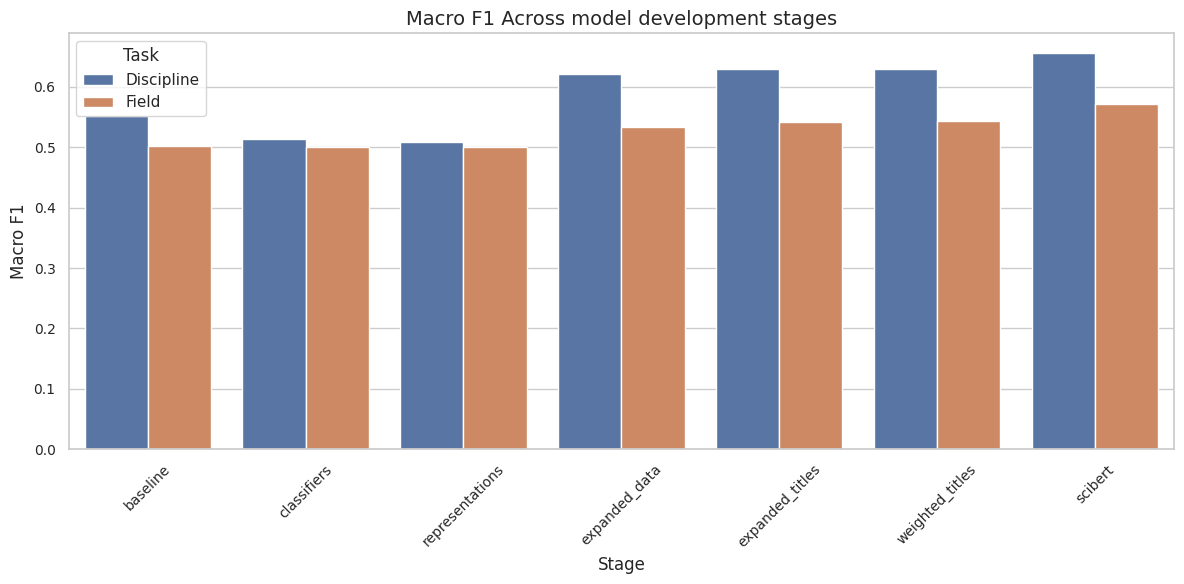

In [35]:
plot_stage_comparison(best_by_stage, "Macro F1")

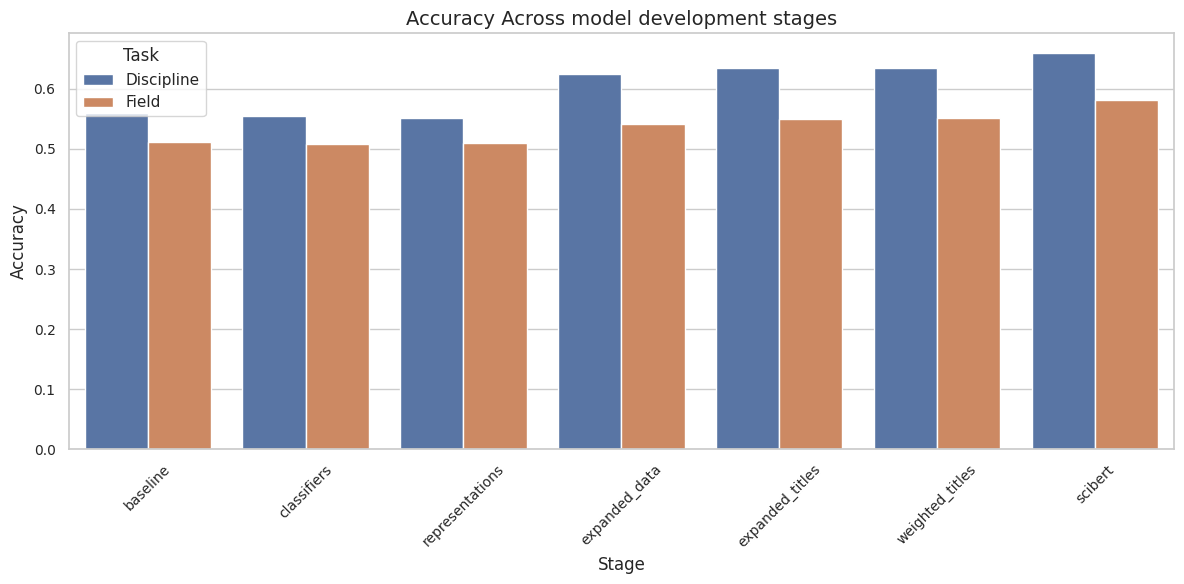

In [36]:
plot_stage_comparison(best_by_stage, "Accuracy")

In [38]:
def plot_progression(df, metric):
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x="Source", y=metric, hue="Task", marker="o")
    plt.title(f"Development of {metric} across stages")
    plt.xlabel("Stage")
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

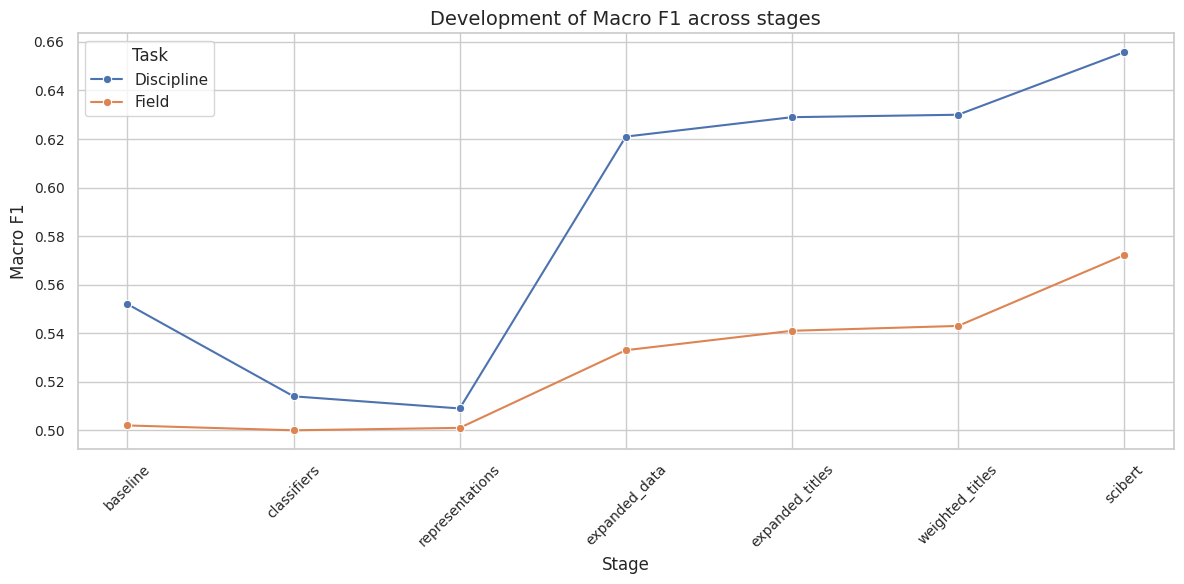

In [39]:
plot_progression(best_by_stage, "Macro F1")

In [42]:
def plot_macro_breakdown(df, task_name):
    plot_df = df[df["Task"] == task_name].copy()

    long_df = plot_df.melt(
        id_vars=["Source"],
        value_vars=["Macro Precision", "Macro Recall", "Macro F1"],
        var_name="Metric",
        value_name="Score"
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=long_df, x="Source", y="Score", hue="Metric")
    plt.title(f"Macro metrics breakdown — {task_name}")
    plt.xlabel("Stage")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

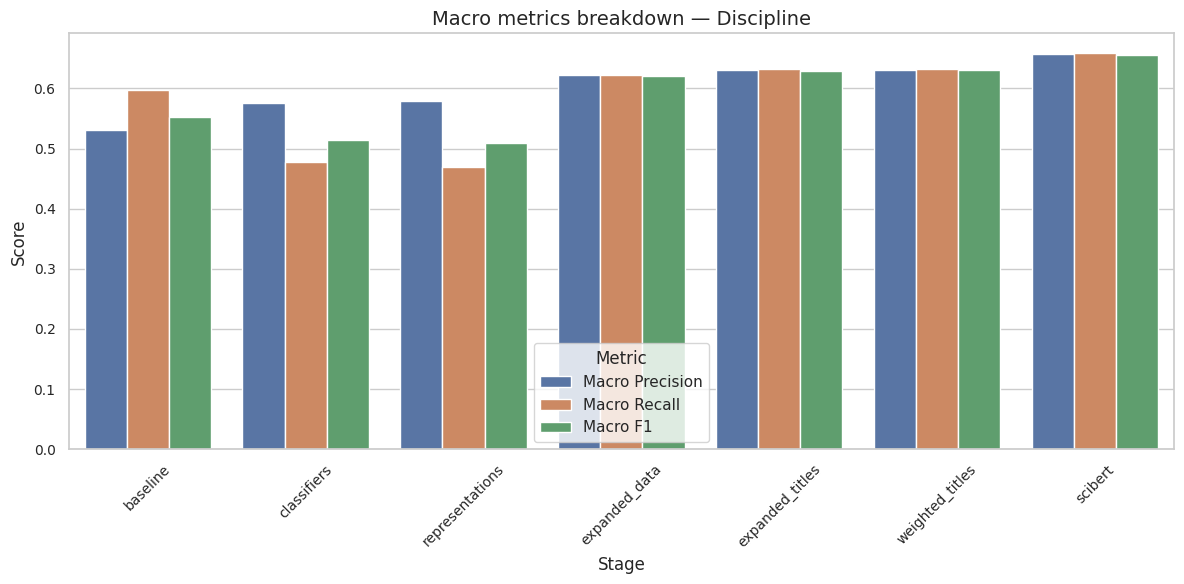

In [43]:
plot_macro_breakdown(best_by_stage, "Discipline")

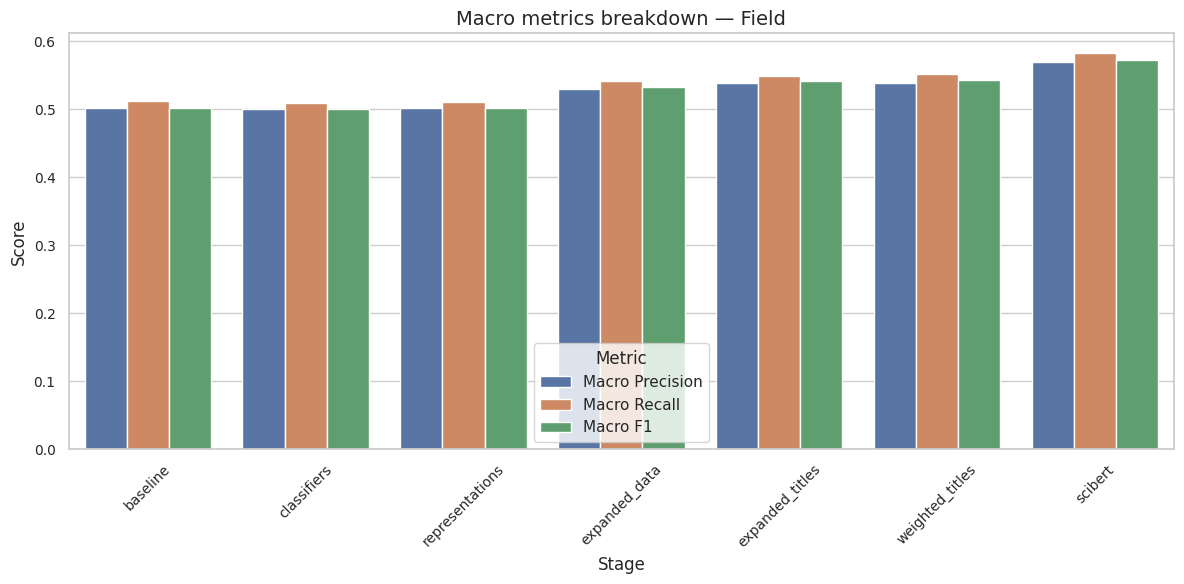

In [44]:
plot_macro_breakdown(best_by_stage, "Field")

In [45]:
best_overall = (
    best_by_stage
    .sort_values(["Task", "Macro F1"], ascending=[True, False])
    .groupby("Task", as_index=False)
    .first()
)

best_overall

,Task,Source,Model,Representation,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Discipline,scibert,SciBERT,"TF-IDF word unigrams (title 3x + abstract, cap...",0.659471,0.657086,0.658640,0.655756,0.631,0.634,0.656353
1,Field,scibert,SciBERT,"TF-IDF word unigrams (title 2x + abstract, unc...",0.581907,0.569593,0.582348,0.572160,0.539,0.551,0.571689


In [46]:
for _, row in best_overall.iterrows():
    print(f"{row['Task']}: best stage = {row['Source']}, Macro F1 = {row['Macro F1']:.3f}, Accuracy = {row['Accuracy']:.3f}")

Discipline: best stage = scibert, Macro F1 = 0.656, Accuracy = 0.659
Field: best stage = scibert, Macro F1 = 0.572, Accuracy = 0.582


In [49]:
baseline_ref = (
    best_by_stage[best_by_stage["Source"] == "baseline"]
    [["Task", "Macro F1", "Accuracy"]]
    .rename(columns={
        "Macro F1": "Baseline macro F1",
        "Accuracy": "Baseline accuracy"
    })
)

improvement_df =best_by_stage.merge(baseline_ref, on="Task", how="left")

improvement_df["Macro F1 gain"] = improvement_df["Macro F1"] - improvement_df["Baseline macro F1"]
improvement_df["Accuracy gain"] = improvement_df["Accuracy"] - improvement_df["Baseline accuracy"]

improvement_df[[
    "Task", "Source", "Macro F1", "Baseline macro F1", "Macro F1 gain", "Accuracy", "Baseline accuracy", "Accuracy gain"
]]

,Task,Source,Macro F1,Baseline macro F1,Macro F1 gain,Accuracy,Baseline accuracy,Accuracy gain
0,Discipline,baseline,0.552000,0.552,0.000000,0.559000,0.559,0.000000
1,Discipline,classifiers,0.514000,0.552,-0.038000,0.555000,0.559,-0.004000
2,Discipline,representations,0.509000,0.552,-0.043000,0.551000,0.559,-0.008000
3,Discipline,expanded_data,0.621000,0.552,0.069000,0.624000,0.559,0.065000
4,Discipline,expanded_titles,0.629000,0.552,0.077000,0.634000,0.559,0.075000
5,Discipline,weighted_titles,0.630000,0.552,0.078000,0.634000,0.559,0.075000
6,Discipline,scibert,0.655756,0.552,0.103756,0.659471,0.559,0.100471
7,Field,baseline,0.502000,0.502,0.000000,0.512000,0.512,0.000000
8,Field,classifiers,0.500000,0.502,-0.002000,0.509000,0.512,-0.003000
9,Field,representations,0.501000,0.502,-0.001000,0.510000,0.512,-0.002000


In [51]:
def plot_improvement(df, metric_gain):
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x="Source", y=metric_gain, hue="Task")
    plt.title(f"{metric_gain} Compared to baseline")
    plt.xlabel("Stage")
    plt.ylabel(metric_gain)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

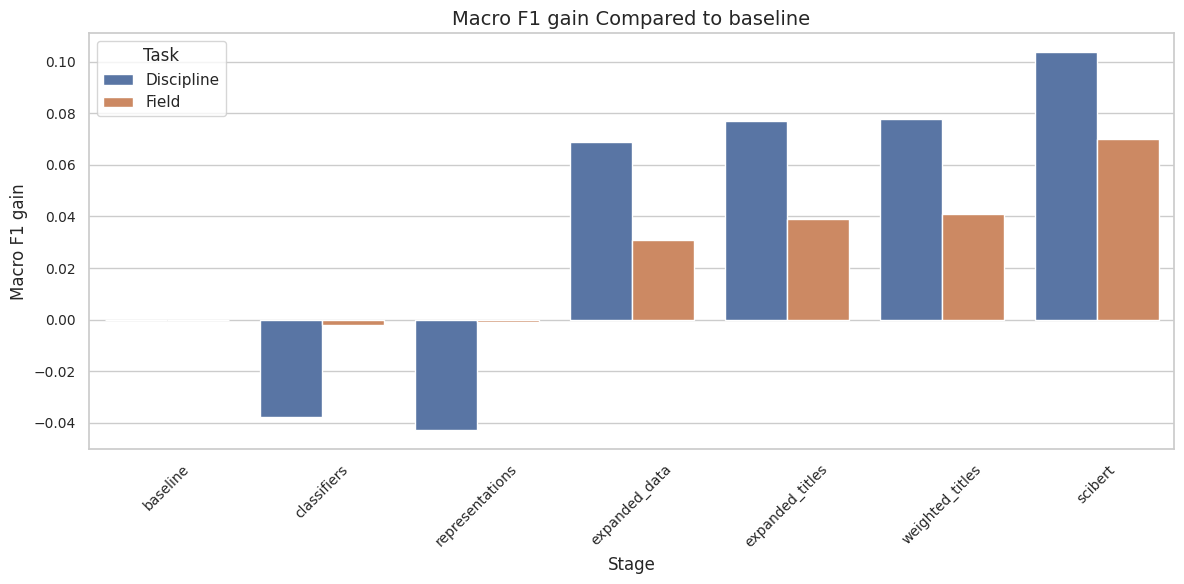

In [52]:
plot_improvement(improvement_df, "Macro F1 gain")

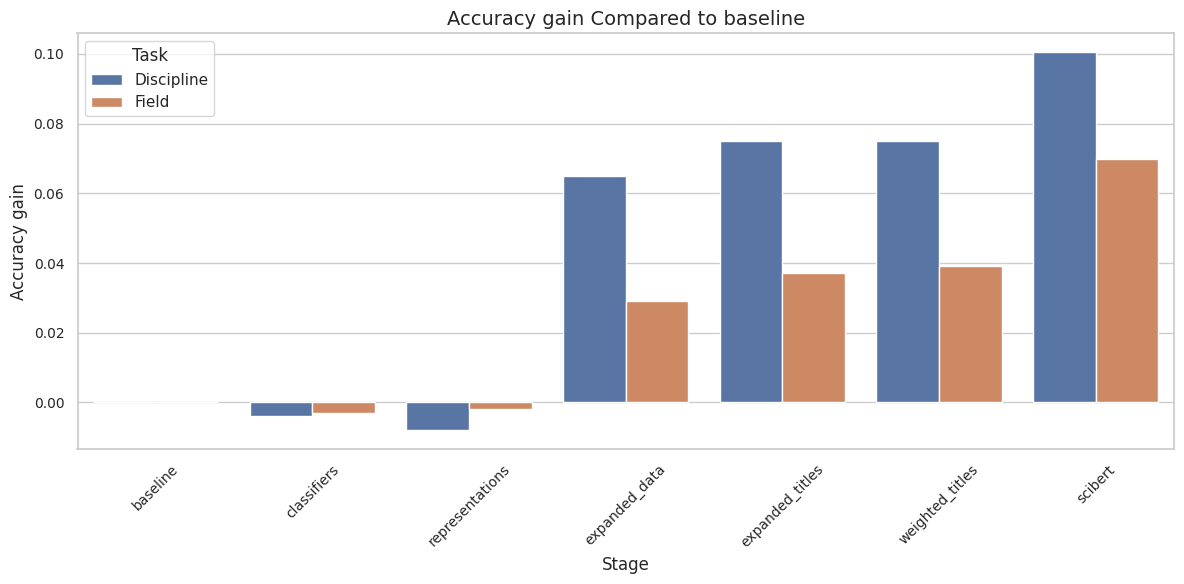

In [54]:
plot_improvement(improvement_df,"Accuracy gain")

In [55]:
# improvement plot helper

def plot_improvement(df, metric_gain):
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x="Source", y=metric_gain, hue="Task")
    plt.title(f"{metric_gain} Compared to baseline")
    plt.xlabel("Stage")
    plt.ylabel(metric_gain)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

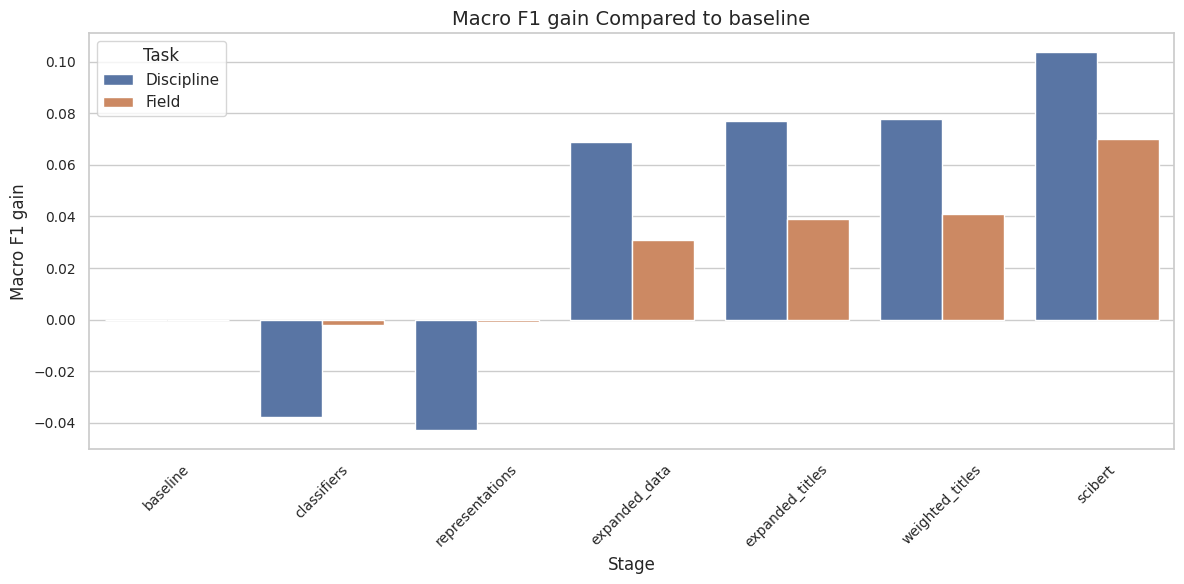

In [56]:
plot_improvement(improvement_df,"Macro F1 gain")

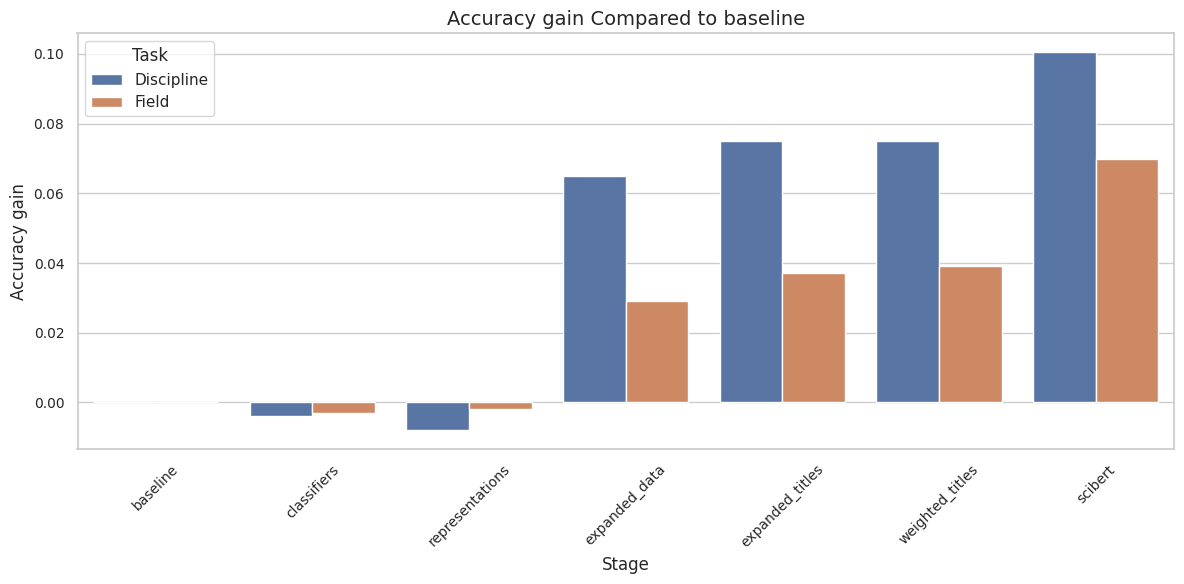

In [57]:
plot_improvement(improvement_df, "Accuracy gain")

In [58]:
def plot_metric_heatmap(df, metric, task_name):
    heatmap_df = (
        df[df["Task"] == task_name].pivot(index="Task", columns="Source", values=metric)
    )

    plt.figure(figsize=(12,3))
    sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="Blues")
    plt.title(f"{metric} Heatmap - {task_name}")
    plt.xlabel("Stage")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

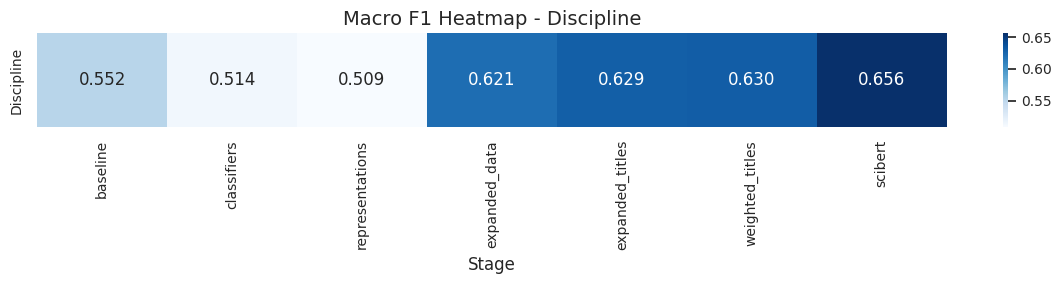

In [59]:
plot_metric_heatmap(best_by_stage, "Macro F1", "Discipline")

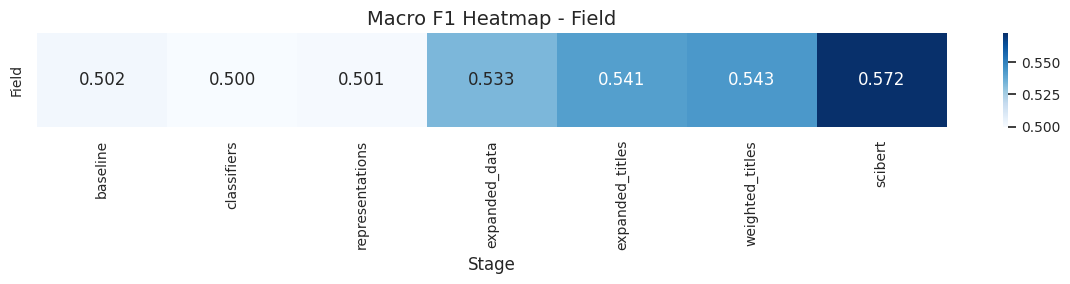

In [60]:
plot_metric_heatmap(best_by_stage, "Macro F1", "Field")

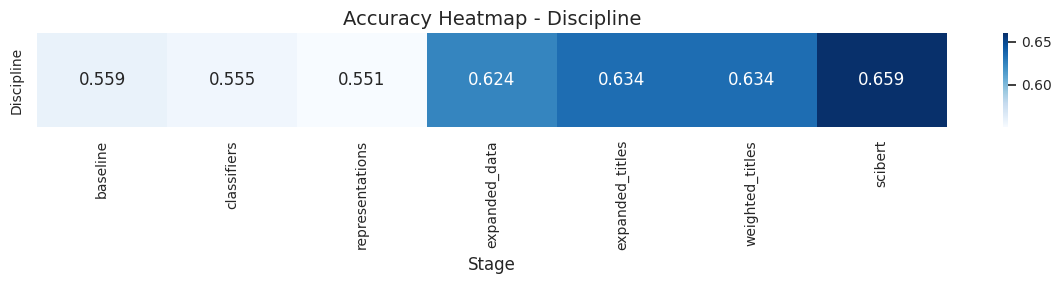

In [61]:
plot_metric_heatmap(best_by_stage, "Accuracy", "Discipline")

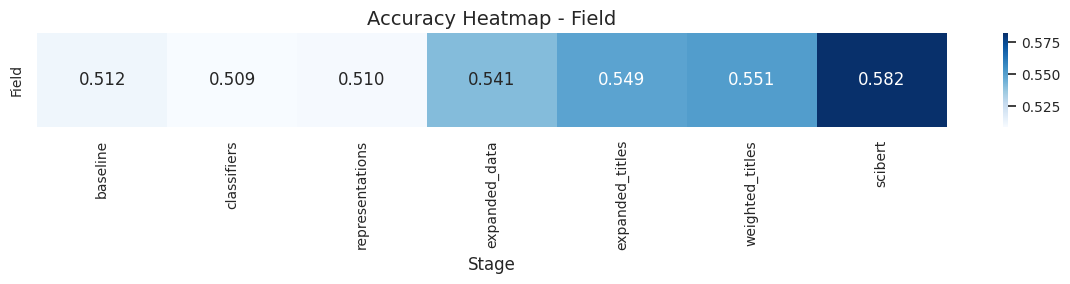

In [62]:
plot_metric_heatmap(best_by_stage, "Accuracy", "Field")

In [66]:
# classical vs. sciBERT

classical_sources = [
    "baseline",
    "classifiers",
    "representations",
    "expanded_data",
    "expanded_titles",
    "weighted_titles"
]

best_classical = (
    best_by_stage[best_by_stage["Source"].isin(classical_sources)]
    .sort_values(["Task", "Macro F1"],ascending=[True, False])
    .groupby("Task", as_index=False)
    .first()
)

scibert_only = best_by_stage[best_by_stage["Source"]=="scibert"].copy()

final_compare = pd.concat([best_classical, scibert_only], ignore_index=True)
final_compare[["Task", "Source", "Model", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"]]

,Task,Source,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Discipline,weighted_titles,Logistic Regression,0.634000,0.631000,0.633000,0.630000,0.631000
1,Field,weighted_titles,Logistic Regression,0.551000,0.539000,0.551000,0.543000,0.543000
2,Discipline,scibert,SciBERT,0.659471,0.657086,0.658640,0.655756,0.656353
3,Field,scibert,SciBERT,0.581907,0.569593,0.582348,0.572160,0.571689


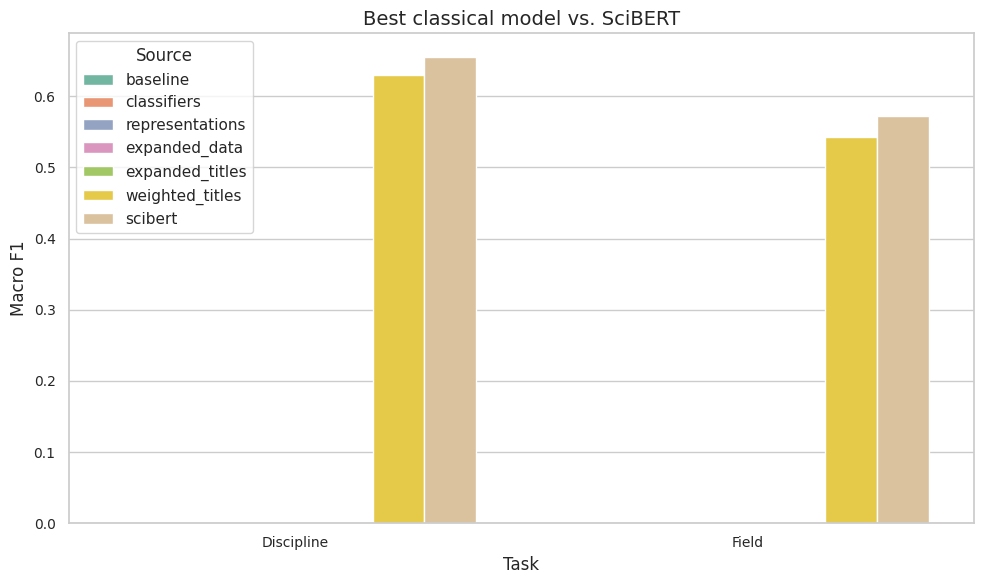

In [68]:
plt.figure(figsize=(10, 6))
sns.barplot(data=final_compare, x="Task", y="Macro F1", hue="Source", palette="Set2")
plt.title("Best classical model vs. SciBERT")
plt.xlabel("Task")
plt.ylabel("Macro F1")
plt.tight_layout()
plt.show()

In [82]:
# title weighing effects

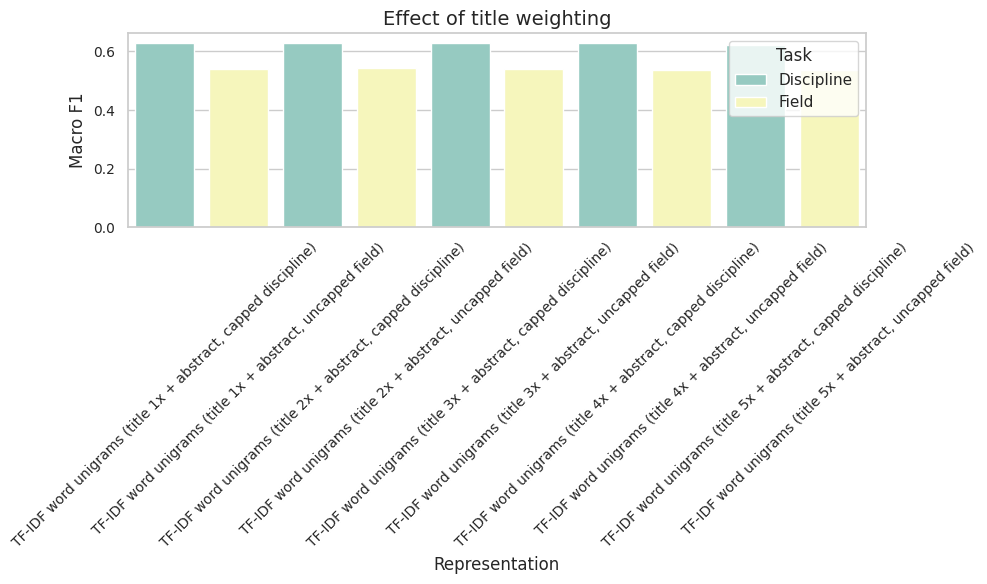

In [85]:
wt = all_results[all_results["Source"] == "weighted_titles"]

plt.figure(figsize=(10, 6))
sns.barplot(data=wt, x="Representation", y="Macro F1", hue="Task", palette="Set3")
plt.title("Effect of title weighting")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

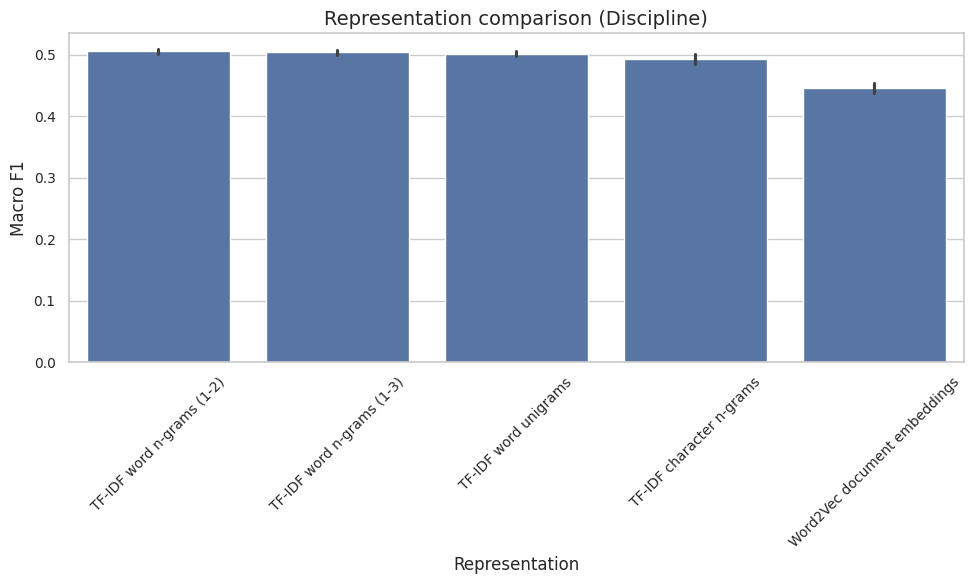

In [86]:
# representation comparison

rep = all_results[all_results["Source"]=="representations"]

plt.figure(figsize=(10, 6))
sns.barplot(data=rep, x="Representation", y="Macro F1")
plt.title("Representation comparison (Discipline)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [87]:
best_by_stage[[
    "Task", "Source", "Model", "Accuracy", "Macro F1"
]]

,Task,Source,Model,Accuracy,Macro F1
0,Discipline,baseline,TF-IDF + Logistic regression,0.559000,0.552000
1,Discipline,classifiers,Logistic Regression,0.555000,0.514000
2,Discipline,representations,Logistic Regression,0.551000,0.509000
3,Discipline,expanded_data,Logistic Regression,0.624000,0.621000
4,Discipline,expanded_titles,Logistic Regression,0.634000,0.629000
5,Discipline,weighted_titles,Logistic Regression,0.634000,0.630000
6,Discipline,scibert,SciBERT,0.659471,0.655756
7,Field,baseline,TF-IDF + Logistic regression,0.512000,0.502000
8,Field,classifiers,Logistic Regression,0.509000,0.500000
9,Field,representations,Logistic Regression,0.510000,0.501000
